<a href="https://colab.research.google.com/github/nishithkumar11/TradeAnalysis/blob/main/RMultipleAnalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [52]:
#Conecting to google drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [53]:
#Importing the file and get file details
import pandas as pd
path = "/content/drive/MyDrive/Finance and Trading/Projects/Trades_AT_PnL.csv"   #update this if your file is in a folder
df = pd.read_csv(path)
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 181 entries, 0 to 180
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Symbol        181 non-null    object 
 1   Realized PnL  181 non-null    float64
dtypes: float64(1), object(1)
memory usage: 3.0+ KB


In [54]:
#Calculate average loss
import numpy as np
avg_loss = abs(df[df["Realized PnL"] < 0]["Realized PnL"].mean())
avg_loss

np.float64(3516.565641025641)

In [55]:
#Calculate R Multiple
df["R_multiple"] = df["Realized PnL"] / avg_loss
df.head()

,Symbol,Realized PnL,R_multiple
0,AADHARHFC,-1688.20,-0.480071
1,AAVAS,-5653.05,-1.607549
2,ACE,-1069.75,-0.304203
3,ACMESOLAR,514.20,0.146222
4,ACUTAAS,853.65,0.242751


In [56]:
#Drop absolute PnL
df = df.drop(columns=["Realized PnL"])
df.head()

,Symbol,R_multiple
0,AADHARHFC,-0.480071
1,AAVAS,-1.607549
2,ACE,-0.304203
3,ACMESOLAR,0.146222
4,ACUTAAS,0.242751


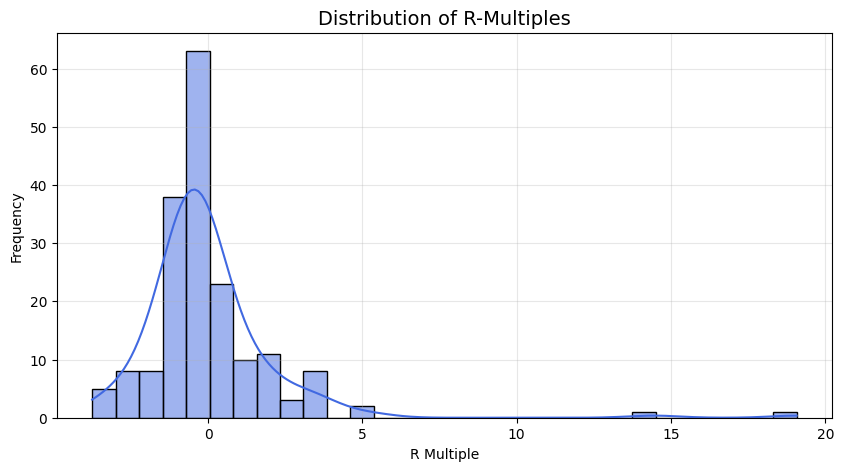

In [57]:
#Histogram
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
sns.histplot(df["R_multiple"], bins=30, kde=True, color="royalblue")
plt.title("Distribution of R-Multiples", fontsize=14)
plt.xlabel("R Multiple")
plt.ylabel("Frequency")
plt.grid(alpha=0.3)
plt.show()

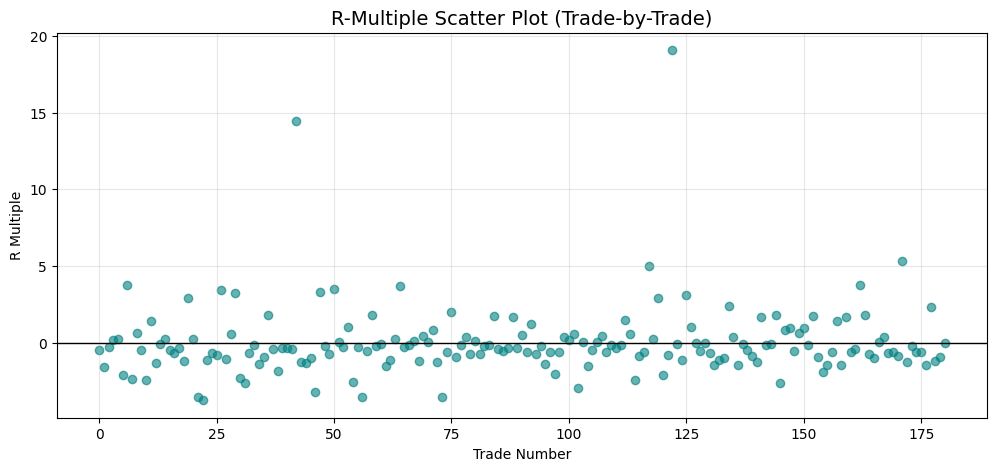

In [58]:
#Scatter Plot
plt.figure(figsize=(12,5))
plt.scatter(range(len(df)), df["R_multiple"], alpha=0.6, color="teal")
plt.axhline(0, color="black", linewidth=1)
plt.title("R-Multiple Scatter Plot (Trade-by-Trade)", fontsize=14)
plt.xlabel("Trade Number")
plt.ylabel("R Multiple")
plt.grid(alpha=0.3)
plt.show()

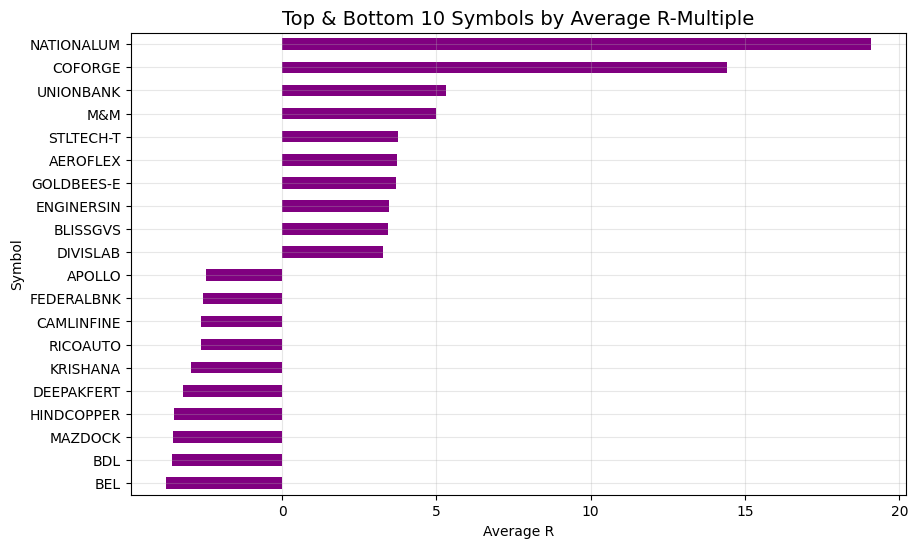

In [59]:
#Top Bottom Performers
symbol_perf = df.groupby("Symbol")["R_multiple"].mean().sort_values()

top_bottom = pd.concat([symbol_perf.head(10), symbol_perf.tail(10)])

plt.figure(figsize=(10,6))
top_bottom.plot(kind="barh", color="purple")
plt.title("Top & Bottom 10 Symbols by Average R-Multiple", fontsize=14)
plt.xlabel("Average R")
plt.grid(alpha=0.3)
plt.show()